# Native Hyperbolic Training for WMD on STS-B

**Author:** Morchid Saad — INSEA — 3D Smart Factory

**Project:** Geometry-Aware Optimal Transport for Interpretable Semantic Textual Similarity (PFE)

## 1. Motivation and hypothesis
The first WMD experiment (`wmd_geometric_comparison.ipynb`) projected Euclidean GloVe 300d vectors into three geometric spaces — flat, spherical, and hyperbolic (via exponential map) — and found the three conditions performed within 0.003 Spearman of each other. The conclusion was that **post-hoc projection cannot introduce geometric structure absent from the training objective**.

This notebook tests the natural follow-up: **does training natively in hyperbolic space — where the model optimizes vectors directly on the Poincaré manifold — improve WMD-based sentence similarity?**

### Hypothesis
If hyperbolic geometry's hierarchical inductive bias is the missing ingredient for WMD on STS-B, native training in hyperbolic space should outperform Euclidean training on the same corpus. The open question this notebook tests is whether *unsupervised* hyperbolic training on co-occurrence statistics — rather than supervised training on hierarchical pairs — can produce gains on sentence-level paraphrase scoring. The HyperLex diagnostic notebook (`hyperbolic_evaluation.ipynb`, presented in the preceding chapter) established that hyperbolic geometry does encode hierarchy when trained on supervised hierarchical data (Nickel & Kiela, 2017). The question this notebook tests is whether *unsupervised* hyperbolic training on co-occurrence statistics can produce similar gains at the sentence level.

### Experimental design
Three native models trained on text8 under identical conditions — same corpus, same vocabulary (50k), same dimensionality (100d), same 20 epochs, same `coocc_func log`. Only the training geometry differs:

| Model | Geometry | Architecture |
|---|---|---|
| Euclidean GloVe (text8) | Flat | 100d standard |
| Poincaré GloVe 25×4d | Hyperbolic | Cartesian product, 25 balls of 4d |
| Poincaré GloVe 50×2d | Hyperbolic | Cartesian product, 50 balls of 2d |

We include both the 25×4d and 50×2d configurations to test architecture sensitivity. The 50×2d Cartesian product is the configuration most prominently featured in Tifrea et al. (2019)'s similarity experiments; running both rules out the possibility that observed performance differences are an artifact of a specific Cartesian product structure.

### Notebook structure
| Section | Content |
|---|---|
| 1 | Motivation and hypothesis (this section) |
| 2 | Setup, data, and models |
| 3 | Training diagnostics and manifold inspection |
| 4 | Shared pipeline and the three cost functions |
| 5 | Main results — table, bootstrap CIs, bar chart, scatter plot |
| 6 | Where the gap comes from — per-pair Wilcoxon, win/loss, hierarchy-rich subset |
| 7 | Transport plan visualization |
| 8 | Discussion — why native geometry did not help WMD |
| 9 | Conclusions and limitations |

## 2. Setup, data, and models

Three native text8 models are loaded under identical preprocessing. All three share the same 50k vocabulary, covering 85.4% of STS-B content words (compared to 96.4% under the larger GloVe 300d vocabulary used in the previous notebook). Since vocabulary is held constant across the three native conditions, coverage differences do not affect the geometry comparison.

In [1]:
# Standard library
import os
import sys
import math
import random
from pathlib import Path
from collections import Counter

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr, wilcoxon
from tqdm import tqdm
import ot

# NLP
import nltk
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
from nltk.corpus import stopwords, wordnet as wn
from nltk.stem import WordNetLemmatizer

# Data
from datasets import load_dataset

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"

print("Imports OK")

Imports OK


In [2]:
# ---- Paths and configuration ----------------------------------------------
BASE_DIR = Path.cwd()
FIGURES_DIR = BASE_DIR / "figures" / "native_hyperbolic_wmd"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EUCLIDEAN_T8_PATH = (
    "/home/saad1/pfe/models/euclidean_glove_text8/"
    "glove_ep20_size100_lr0.05_vocab50000_euclid_"
    "OPTadagrad_COOCCFUNClog_DISTFUNCdist-sq_bias"
)

POINCARE_25x4_PATH = (
    "/home/saad1/pfe/models/poincare_glove_text8_25x4d/"
    "glove_ep20_size100_lr0.005_vocab50000_mix-poincare_"
    "OPTmixradagrad_COOCCFUNClog_DISTFUNCcosh-dist-sq_NUMEMBS25_bias"
)

POINCARE_50x2_PATH = (
    "/home/saad1/pfe/models/poincare_glove_text8_50x2d/"
    "glove_ep20_size100_lr0.005_vocab50000_mix-poincare_"
    "OPTmixradagrad_COOCCFUNClog_DISTFUNCcosh-dist-sq_NUMEMBS50_bias"
)

# Poincaré GloVe architecture parameters
NUM_EMBS_25 = 25
CHUNK_DIM_25 = 4

NUM_EMBS_50 = 50
CHUNK_DIM_50 = 2

STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

print(f"Working directory: {BASE_DIR}")
print(f"Figures directory: {FIGURES_DIR}")

Working directory: /home/saad1/pfe
Figures directory: /home/saad1/pfe/figures/native_hyperbolic_wmd


In [3]:
# ---- Load text8 models (Tifrea fork's gensim) -----------------------------
# Insert Tifrea path first to load the saved KeyedVectors objects
sys.path.insert(0, "/home/saad1/poincare_glove")
from gensim.models import KeyedVectors

print("Loading Euclidean GloVe (text8, 100d)...")
MODEL_EUC = KeyedVectors.load(EUCLIDEAN_T8_PATH)
euc_vocab = MODEL_EUC.wv if hasattr(MODEL_EUC, 'wv') else MODEL_EUC

print("Loading Poincaré GloVe (text8, 25×4d)...")
MODEL_P25 = KeyedVectors.load(POINCARE_25x4_PATH)
p25_vocab = MODEL_P25.wv if hasattr(MODEL_P25, 'wv') else MODEL_P25

print("Loading Poincaré GloVe (text8, 50×2d)...")
MODEL_P50 = KeyedVectors.load(POINCARE_50x2_PATH)
p50_vocab = MODEL_P50.wv if hasattr(MODEL_P50, 'wv') else MODEL_P50

# Extract embedding dicts so we can drop the Tifrea fork dependency
def extract_dict(vocab):
    # Old gensim uses .vocab; access vectors directly
    if hasattr(vocab, 'vocab'):
        words = list(vocab.vocab.keys())
    else:
        words = list(vocab.key_to_index.keys())
    return {w: np.array(vocab[w], dtype=np.float64) for w in words}

print("\nExtracting embedding dicts...")
EUC = extract_dict(euc_vocab)
P25 = extract_dict(p25_vocab)
P50 = extract_dict(p50_vocab)

print(f"  Euclidean: {len(EUC):,} words, {len(next(iter(EUC.values())))}d")
print(f"  P25×4d:    {len(P25):,} words, {len(next(iter(P25.values())))}d")
print(f"  P50×2d:    {len(P50):,} words, {len(next(iter(P50.values())))}d")

Loading Euclidean GloVe (text8, 100d)...
Loading Poincaré GloVe (text8, 25×4d)...
Loading Poincaré GloVe (text8, 50×2d)...

Extracting embedding dicts...
  Euclidean: 50,000 words, 100d
  P25×4d:    50,000 words, 100d
  P50×2d:    50,000 words, 100d


In [4]:
# ---- Load STS-B -----------------------------------------------------------
print("Loading STS-B...")
stsb = load_dataset("nyu-mll/glue", "stsb")
print(f"  Train: {len(stsb['train']):,} | Validation: {len(stsb['validation']):,}")

# Quick sanity: are vocabs identical across text8 models?
print(f"\nVocab sizes:")
print(f"  EUC:  {len(EUC):,}")
print(f"  P25:  {len(P25):,}")
print(f"  P50:  {len(P50):,}")
shared = set(EUC.keys()) & set(P25.keys()) & set(P50.keys())
print(f"  Shared across all three: {len(shared):,}")
print(f"  Identical: {set(EUC.keys()) == set(P25.keys()) == set(P50.keys())}")

Loading STS-B...


  Train: 5,749 | Validation: 1,500

Vocab sizes:
  EUC:  50,000
  P25:  50,000
  P50:  50,000
  Shared across all three: 50,000
  Identical: True


## 3. Training diagnostics and manifold inspection

Before evaluating the models on STS-B, we verify that training converged and inspect where the resulting embeddings sit on the manifold. This section addresses three questions:

1. **Did training proceed normally?** Per-word norm statistics across the three models, confirming vectors are well-defined and Poincaré vectors stay inside the unit ball.
2. **Did training converge?** Per-epoch loss curves for both Poincaré architectures.
3. **Where do the vectors actually live on the manifold?** Full-vocabulary scatter plots on selected 2D disks, plus a curated semantic plot showing where interpretable categories land.

The findings here feed directly into the discussion: the Poincaré models train correctly and learn coherent structure, but that structure (associative-contextual, compressed near the origin) is not the hierarchical-radial structure that distinguishes hyperbolic from Euclidean space.

In [5]:
# ---- Quick sanity check ---------------------------------------------------
test_word = "dog"
print(f"Sanity check for '{test_word}':")
print(f"  Euclidean norm:  {np.linalg.norm(EUC[test_word]):.4f}")
print(f"  P25×4d norm:     {np.linalg.norm(P25[test_word]):.4f}")
print(f"  P50×2d norm:     {np.linalg.norm(P50[test_word]):.4f}")

# Verify all P25 vectors satisfy ||v_chunk|| < 1 per ball
p25_max_chunk = 0
for w in list(P25.keys())[:1000]:
    v = P25[w]
    for k in range(NUM_EMBS_25):
        chunk = v[k*CHUNK_DIM_25:(k+1)*CHUNK_DIM_25]
        n = np.linalg.norm(chunk)
        p25_max_chunk = max(p25_max_chunk, n)
print(f"\nP25 max chunk norm (should be < 1):  {p25_max_chunk:.4f}")

p50_max_chunk = 0
for w in list(P50.keys())[:1000]:
    v = P50[w]
    for k in range(NUM_EMBS_50):
        chunk = v[k*CHUNK_DIM_50:(k+1)*CHUNK_DIM_50]
        n = np.linalg.norm(chunk)
        p50_max_chunk = max(p50_max_chunk, n)
print(f"P50 max chunk norm (should be < 1):  {p50_max_chunk:.4f}")

Sanity check for 'dog':
  Euclidean norm:  1.7712
  P25×4d norm:     0.1751
  P50×2d norm:     0.1817

P25 max chunk norm (should be < 1):  0.2450
P50 max chunk norm (should be < 1):  0.2073


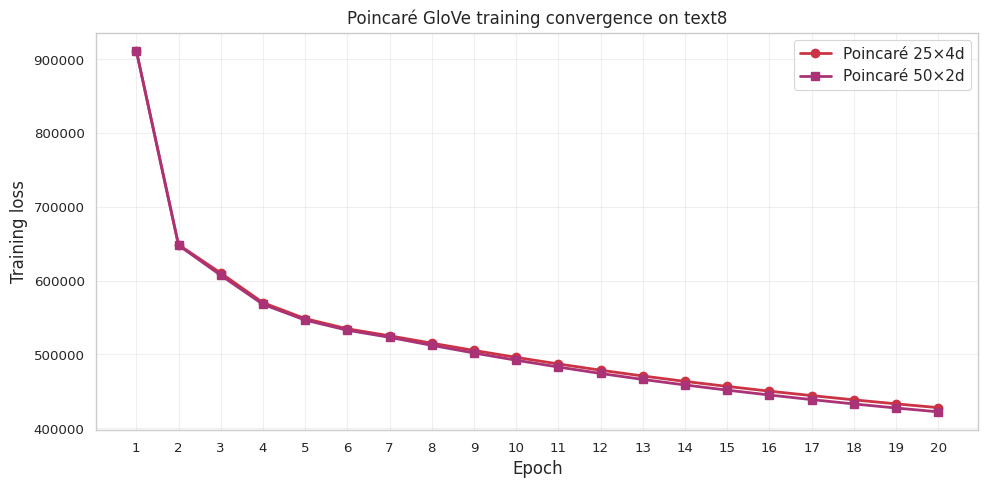

Final losses (lower is better, but only comparable within model):
  Poincaré 25×4d: 427,920  (53.1% reduction)
  Poincaré 50×2d: 422,209  (53.7% reduction)

Both curves still descending at epoch 20.


In [6]:
# ---- Training loss curves for both Poincaré architectures -----------------
# Both models optimize the same cosh-dist-sq objective. Euclidean GloVe is
# not included since it optimizes a different objective and absolute loss
# values would not be comparable.

loss_p25 = [
    911861.875, 648808.6875, 610375.6875, 570217.0625, 548555.3125,
    534801.0625, 525287.875,  515310.09375, 505494.65625, 496076.53125,
    487143.375,  478675.6875, 470828.875,  463484.6875, 456696.96875,
    450274.4375, 444239.96875,438497.125,  433068.21875,427920.34375,
]

loss_p50 = [
    911766.6875, 647946.75,   607304.3125, 567938.6875, 546582.6875,
    532815.25,   523209.25,   512359.71875,501991.1875, 492191.40625,
    482957.6875, 474259.09375,466129.21875,458669.78125,451638.25,
    445035.8125, 438809.4375, 432931.09375,427444.15625,422209.125,
]

epochs = list(range(1, 21))

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs, loss_p25, marker="o", linewidth=2, markersize=6,
        color="#CC3344", label="Poincaré 25×4d")
ax.plot(epochs, loss_p50, marker="s", linewidth=2, markersize=6,
        color="#AA3377", label="Poincaré 50×2d")

ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Training loss", fontsize=12)
ax.set_title("Poincaré GloVe training convergence on text8", fontsize=12)
ax.set_xticks(epochs)
ax.legend(fontsize=11, loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "training_loss_poincare.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Final losses (lower is better, but only comparable within model):")
print(f"  Poincaré 25×4d: {loss_p25[-1]:,.0f}  ({100*(loss_p25[0]-loss_p25[-1])/loss_p25[0]:.1f}% reduction)")
print(f"  Poincaré 50×2d: {loss_p50[-1]:,.0f}  ({100*(loss_p50[0]-loss_p50[-1])/loss_p50[0]:.1f}% reduction)")
print(f"\nBoth curves still descending at epoch 20.")

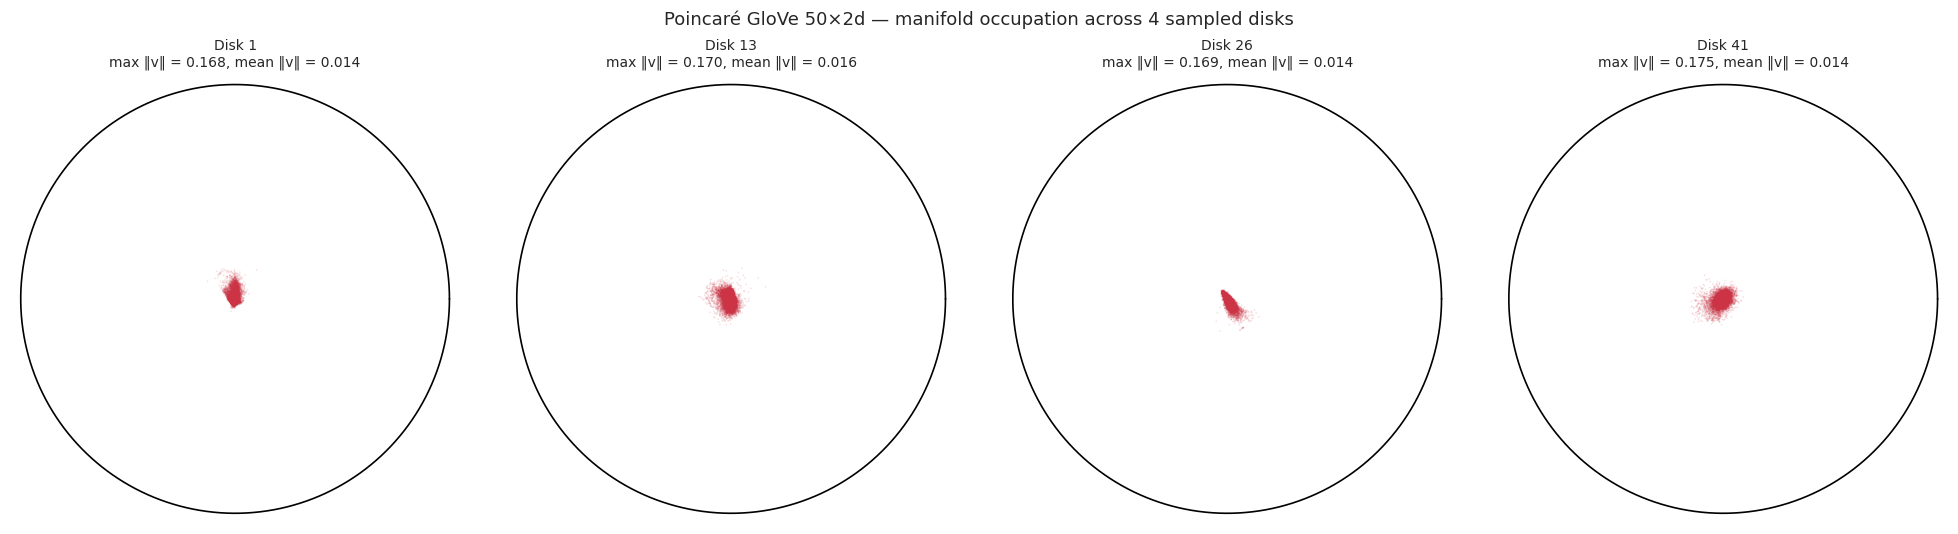

Maximum ‖v_chunk‖ across all 50 disks: 0.2073
Vectors occupy only ~21% of the available radius —
consistent with the inner-region clustering visible in Tifrea Figures 5-6.


In [7]:
# ---- Poincaré disks: all 50k vocabulary points across 4 sampled disks -----
# Reproduces the style of Tifrea et al. (2019) Figures 5-6. Each subplot
# shows all 50,000 words projected into one of the 50 component 2D disks.

all_words = list(P50.keys())
all_vecs_p50 = np.stack([P50[w] for w in all_words])

disk_indices = [0, 12, 25, 40]

fig, axes = plt.subplots(1, 4, figsize=(20, 5.2))

for ax, k in zip(axes, disk_indices):
    chunk = all_vecs_p50[:, k * CHUNK_DIM_50 : (k + 1) * CHUNK_DIM_50]
    
    # Draw the unit-disk boundary
    theta = np.linspace(0, 2 * np.pi, 200)
    ax.plot(np.cos(theta), np.sin(theta), color="black", linewidth=1.2)
    
    ax.scatter(chunk[:, 0], chunk[:, 1],
               s=1.5, alpha=0.15, color="#CC3344", edgecolor="none")
    
    norms = np.linalg.norm(chunk, axis=1)
    ax.set_title(f"Disk {k + 1}\nmax ‖v‖ = {norms.max():.3f}, mean ‖v‖ = {norms.mean():.3f}",
                 fontsize=10)
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.set_aspect("equal")
    ax.axis("off")

plt.suptitle("Poincaré GloVe 50×2d — manifold occupation across 4 sampled disks",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "poincare_disks_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# Occupancy summary across all 50 disks
all_max_norms = [
    np.linalg.norm(all_vecs_p50[:, k*CHUNK_DIM_50:(k+1)*CHUNK_DIM_50], axis=1).max()
    for k in range(NUM_EMBS_50)
]
print(f"Maximum ‖v_chunk‖ across all 50 disks: {max(all_max_norms):.4f}")
print(f"Vectors occupy only ~{100 * max(all_max_norms):.0f}% of the available radius —")
print(f"consistent with the inner-region clustering visible in Tifrea Figures 5-6.")

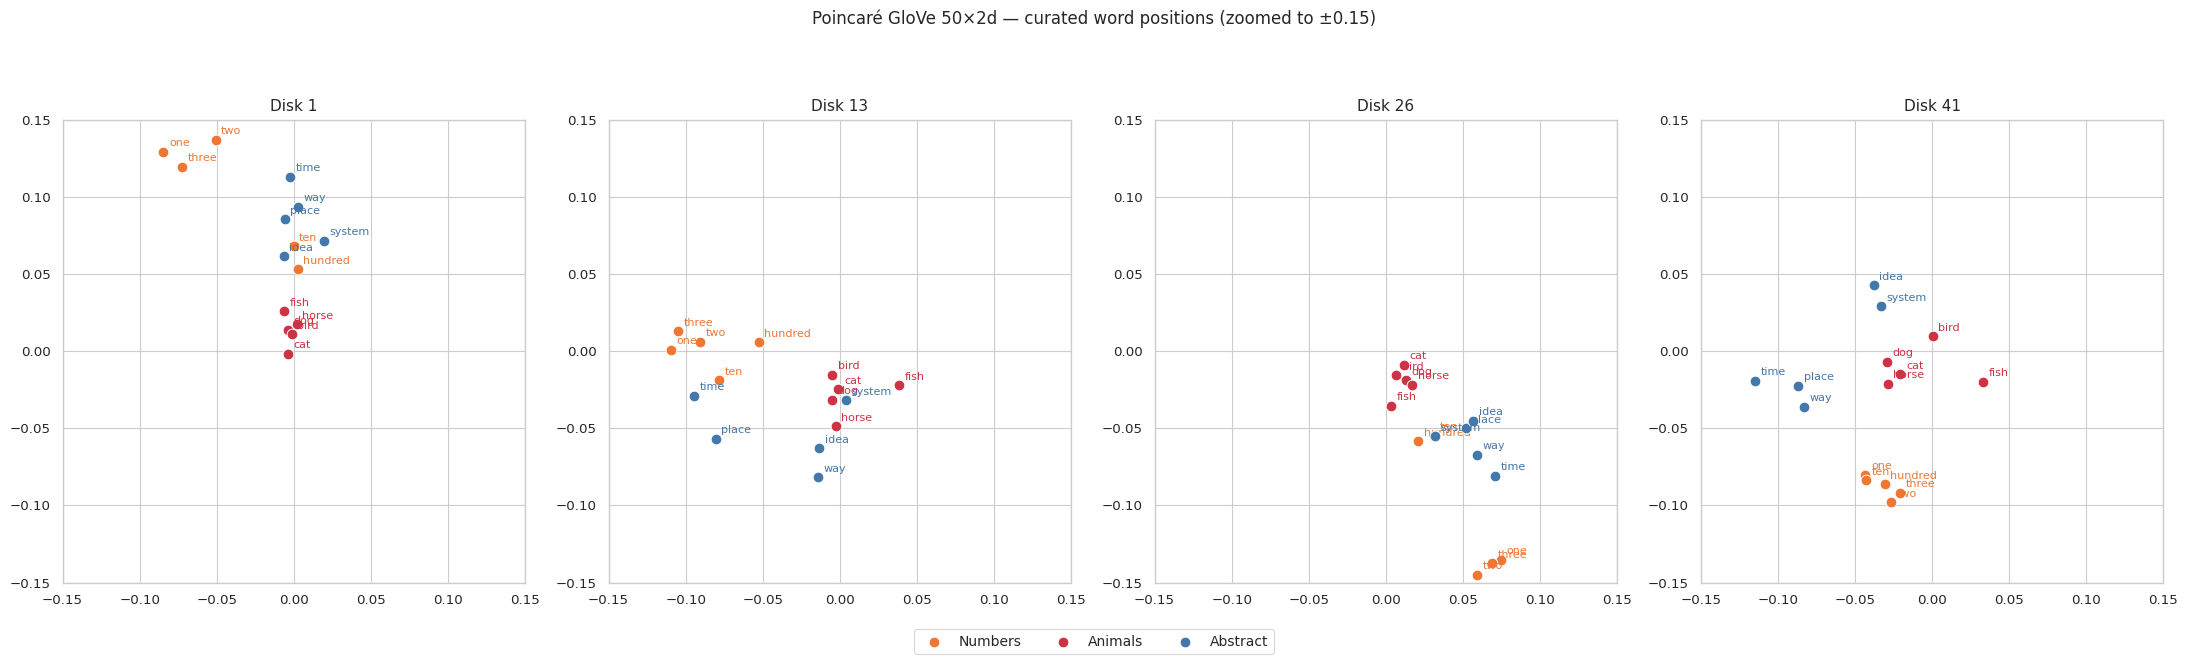

Plotted 15 words across 3 categories.


In [8]:
# ---- Poincaré disks: curated word positions across 4 sampled disks ---------
# Hand-picked words from 3 distinguishable categories, plotted in the inner
# region where vectors actually live.

curated = {
    "Numbers":  ["one", "two", "three", "ten", "hundred"],
    "Animals":  ["dog", "cat", "horse", "bird", "fish"],
    "Abstract": ["time", "place", "idea", "way", "system"],
}
category_colors = {
    "Numbers":  "#EE7733",
    "Animals":  "#CC3344",
    "Abstract": "#4477AA",
}
curated = {cat: [w for w in words if w in P50] for cat, words in curated.items()}

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
for ax, k in zip(axes, disk_indices):
    theta = np.linspace(0, 2 * np.pi, 200)
    ax.plot(np.cos(theta), np.sin(theta), color="black", linewidth=1.2)
    for category, words in curated.items():
        xs, ys = [], []
        for w in words:
            chunk = P50[w][k * CHUNK_DIM_50 : (k + 1) * CHUNK_DIM_50]
            xs.append(chunk[0]); ys.append(chunk[1])
        ax.scatter(xs, ys, s=60, color=category_colors[category],
                   label=category, edgecolor="white", linewidth=0.7, zorder=3)
        for w, x, y in zip(words, xs, ys):
            ax.annotate(w, (x, y), fontsize=8,
                        xytext=(4, 4), textcoords="offset points",
                        color=category_colors[category])
    ax.set_title(f"Disk {k + 1}", fontsize=11)
    ax.set_xlim(-0.15, 0.15)
    ax.set_ylim(-0.15, 0.15)
    ax.set_aspect("equal")
    # ax.axis("off")
    
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.02),
           ncol=3, fontsize=10, frameon=True)

plt.suptitle("Poincaré GloVe 50×2d — curated word positions (zoomed to ±0.15)",
             fontsize=12, y=1.04)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "poincare_disks_semantic.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Plotted {sum(len(w) for w in curated.values())} words across {len(curated)} categories.")

## 4. Shared pipeline and the three cost functions

The pipeline (tokenization → lemmatization → TF-IDF → exact EMD) is identical across all three conditions. Only the cost matrix differs.

### Cost functions

| Model | Distance | Formula |
|---|---|---|
| Euclidean | L2 | $\|u - v\|_2$ |
| Poincaré 25×4d | Product Poincaré | $\sum_{k=1}^{25} \mathrm{arccosh}\left(1 + \frac{2\|u_k - v_k\|^2}{(1-\|u_k\|^2)(1-\|v_k\|^2)}\right)$ |
| Poincaré 50×2d | Product Poincaré | $\sum_{k=1}^{50} \mathrm{arccosh}\left(1 + \frac{2\|u_k - v_k\|^2}{(1-\|u_k\|^2)(1-\|v_k\|^2)}\right)$ |

For both Poincaré models, the cost is defined as the sum of component-wise Poincaré distances across the Cartesian product of balls.

In [9]:
# ---- Tokenization ---------------------------------------------------------
def tokenize(text, vocab):
    """Tokenize, remove punctuation/stopwords, lemmatize, filter to vocab."""
    for ch in '.,!?;:"\'()[]{}—–-/':
        text = text.replace(ch, " ")
    known = []
    for w in text.lower().split():
        if w in STOP_WORDS or len(w) < 2:
            continue
        w = LEMMATIZER.lemmatize(w)
        if w in vocab:
            known.append(w)
    return known


def get_content_words(text):
    """Extract content words without vocab filtering (for hierarchy detection)."""
    for ch in '.,!?;:"\'()[]{}—–-/':
        text = text.replace(ch, " ")
    out = []
    for w in text.lower().split():
        if w in STOP_WORDS or len(w) < 2:
            continue
        out.append(LEMMATIZER.lemmatize(w))
    return out


# ---- IDF from STS-B train -------------------------------------------------
print("Computing IDF on STS-B train (using Euclidean vocab as reference)...")
docs = []
for ex in stsb["train"]:
    docs.append(tokenize(ex["sentence1"], EUC))
    docs.append(tokenize(ex["sentence2"], EUC))

N = len(docs)
df = Counter()
for doc in docs:
    for w in set(doc):
        df[w] += 1
IDF = {w: math.log(N / (1 + f)) for w, f in df.items()}
IDF_DEFAULT = math.log(N)
print(f"  IDF computed for {len(IDF):,} words")


def compute_weights(tokens):
    """TF-IDF weights normalized to sum to 1."""
    if not tokens:
        return [], np.array([])
    counts = Counter(tokens)
    total = len(tokens)
    words, weights = [], []
    for w, c in counts.items():
        tf = c / total
        idf = IDF.get(w, IDF_DEFAULT)
        words.append(w)
        weights.append(tf * idf)
    weights = np.array(weights, dtype=np.float64)
    weights /= weights.sum()
    order = np.argsort(-weights)
    return [words[i] for i in order], weights[order]


print("Pipeline ready.")

Computing IDF on STS-B train (using Euclidean vocab as reference)...
  IDF computed for 7,989 words
Pipeline ready.


In [10]:
# ---- Cost functions -------------------------------------------------------

def cost_euclidean(words_a, words_b):
    """L2 distance between Euclidean text8 vectors."""
    va = np.array([EUC[w] for w in words_a])
    vb = np.array([EUC[w] for w in words_b])
    sq_a = np.sum(va**2, axis=1, keepdims=True)
    sq_b = np.sum(vb**2, axis=1, keepdims=True)
    C = np.sqrt(np.maximum(sq_a + sq_b.T - 2 * va @ vb.T, 0.0))
    return C


def _product_poincare_cost(va, vb, num_embs, chunk_dim):
    """Sum of Poincaré distances across Cartesian product balls."""
    n, m = len(va), len(vb)
    C = np.zeros((n, m))
    
    for k in range(num_embs):
        s = k * chunk_dim
        e = s + chunk_dim
        ua = va[:, s:e]
        ub = vb[:, s:e]
        
        norm_a = np.sum(ua**2, axis=1, keepdims=True)
        norm_b = np.sum(ub**2, axis=1, keepdims=True)
        
        # Clip to keep strictly inside the ball
        norm_a = np.clip(norm_a, 0.0, 1.0 - 1e-7)
        norm_b = np.clip(norm_b, 0.0, 1.0 - 1e-7)
        
        diff_sq = norm_a + norm_b.T - 2 * ua @ ub.T
        diff_sq = np.maximum(diff_sq, 0.0)
        
        denom = (1 - norm_a) * (1 - norm_b.T)
        denom = np.maximum(denom, 1e-10)
        
        arg = 1 + 2 * diff_sq / denom
        arg = np.maximum(arg, 1.0 + 1e-10)
        
        C += np.arccosh(arg)
    
    return C


def cost_poincare_25(words_a, words_b):
    """Cartesian product Poincaré distance for 25×4d model."""
    va = np.array([P25[w] for w in words_a])
    vb = np.array([P25[w] for w in words_b])
    return _product_poincare_cost(va, vb, NUM_EMBS_25, CHUNK_DIM_25)


def cost_poincare_50(words_a, words_b):
    """Cartesian product Poincaré distance for 50×2d model."""
    va = np.array([P50[w] for w in words_a])
    vb = np.array([P50[w] for w in words_b])
    return _product_poincare_cost(va, vb, NUM_EMBS_50, CHUNK_DIM_50)


print("Cost functions ready.")

Cost functions ready.


In [11]:
# Check nearest neighbors for "dog" in each model
def nearest_neighbors(word, vocab_dict, cost_fn, k=10):
    target = vocab_dict[word]
    all_words = list(vocab_dict.keys())[:5000]  # top 5k for speed
    # Compute distance from word to all others
    others = [w for w in all_words if w != word and w in vocab_dict]
    C = cost_fn([word], others)
    distances = C[0]
    order = np.argsort(distances)
    return [(others[i], distances[i]) for i in order[:k]]

print("Nearest to 'dog' in Euclidean text8:")
for w, d in nearest_neighbors("dog", EUC, cost_euclidean): print(f"  {w}: {d:.3f}")

print("\nNearest to 'dog' in Poincaré 25×4d:")
for w, d in nearest_neighbors("dog", P25, cost_poincare_25): print(f"  {w}: {d:.3f}")

print("\nNearest to 'dog' in Poincaré 50×2d:")
for w, d in nearest_neighbors("dog", P50, cost_poincare_50): print(f"  {w}: {d:.3f}")

Nearest to 'dog' in Euclidean text8:
  cat: 1.063
  dogs: 1.169
  bear: 1.258
  horse: 1.274
  girl: 1.333
  bird: 1.362
  wearing: 1.407
  giant: 1.431
  baby: 1.443
  horses: 1.457

Nearest to 'dog' in Poincaré 25×4d:
  cat: 0.581
  giant: 0.779
  tail: 0.924
  blade: 0.932
  creature: 0.935
  strange: 0.937
  monster: 0.940
  grave: 0.947
  bird: 0.947
  firm: 0.963

Nearest to 'dog' in Poincaré 50×2d:
  cat: 0.891
  giant: 1.092
  bear: 1.315
  blade: 1.327
  monster: 1.338
  creature: 1.353
  bird: 1.359
  tail: 1.360
  horse: 1.372
  reader: 1.381


In [12]:
# ---- WMD function ---------------------------------------------------------
def wmd(text_a, text_b, cost_fn, vocab):
    tokens_a = tokenize(text_a, vocab)
    tokens_b = tokenize(text_b, vocab)
    words_a, weights_a = compute_weights(tokens_a)
    words_b, weights_b = compute_weights(tokens_b)
    
    if not words_a or not words_b:
        return {"score": float("inf"), "error": "empty"}
    
    C = cost_fn(words_a, words_b)
    wa = weights_a / weights_a.sum()
    wb = weights_b / weights_b.sum()
    T = ot.emd(wa, wb, C)
    
    return {
        "score": float(np.sum(T * C)),
        "T": T, "C": C,
        "words_a": words_a, "words_b": words_b,
        "weights_a": wa, "weights_b": wb,
    }


print("WMD function ready.")

WMD function ready.


## 5. Main results

All three native models are evaluated on the 1500 STS-B validation pairs. The text8 vocabulary is identical across models, so each evaluation operates on the same effective set of pairs and the comparison is matched at the pair level.

We report Spearman ρ as the primary metric (since human ratings are ordinal), accompanied by Pearson r, 95% bootstrap confidence intervals on Spearman, a bar chart with error bars, and per-model scatter plots of predicted score against human rating.

In [13]:
def evaluate(dataset, cost_fn, vocab, label):
    scores, labels, indices = [], [], []
    failed = 0
    
    for idx, ex in enumerate(tqdm(dataset, desc=label)):
        r = wmd(ex["sentence1"], ex["sentence2"], cost_fn, vocab)
        if r["score"] == float("inf"):
            failed += 1
            continue
        scores.append(r["score"])
        labels.append(ex["label"])
        indices.append(idx)
    
    scores = np.array(scores)
    labels = np.array(labels)
    rho, _ = spearmanr(-scores, labels)
    r, _ = pearsonr(-scores, labels)
    print(f"  {label}: ρ = {rho:.4f}, r = {r:.4f}, failed = {failed}/{len(dataset)}")
    return {"label": label, "scores": scores, "labels": labels,
            "indices": indices, "spearman": rho, "pearson": r, "failed": failed}


print("Evaluating all three native models on STS-B validation...\n")

res_euc = evaluate(stsb["validation"], cost_euclidean,    EUC, "Euclidean (text8)")
res_p25 = evaluate(stsb["validation"], cost_poincare_25,  P25, "Poincaré 25×4d")
res_p50 = evaluate(stsb["validation"], cost_poincare_50,  P50, "Poincaré 50×2d")

Evaluating all three native models on STS-B validation...



Euclidean (text8): 100%|██████████████████████████████████████████████████████████| 1500/1500 [00:00<00:00, 2198.11it/s]


  Euclidean (text8): ρ = 0.7009, r = 0.6965, failed = 0/1500


Poincaré 25×4d: 100%|██████████████████████████████████████████████████████████████| 1500/1500 [00:02<00:00, 682.15it/s]


  Poincaré 25×4d: ρ = 0.6163, r = 0.6101, failed = 0/1500


Poincaré 50×2d: 100%|██████████████████████████████████████████████████████████████| 1500/1500 [00:04<00:00, 373.35it/s]

  Poincaré 50×2d: ρ = 0.6184, r = 0.6119, failed = 0/1500


In [14]:
# ---- Results table --------------------------------------------------------
all_res = [res_euc, res_p25, res_p50]

results_df = pd.DataFrame([{
    "Method": r["label"],
    "Spearman ρ": r["spearman"],
    "Pearson r":  r["pearson"],
    "Valid pairs": len(r["scores"]),
    "Failed":     r["failed"],
} for r in all_res])

print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
results_df.to_csv(FIGURES_DIR / "main_results.csv", index=False)

           Method  Spearman ρ  Pearson r  Valid pairs  Failed
Euclidean (text8)      0.7009     0.6965         1500       0
   Poincaré 25×4d      0.6163     0.6101         1500       0
   Poincaré 50×2d      0.6184     0.6119         1500       0


In [15]:
# ---- Bootstrap 95% CIs ----------------------------------------------------
def bootstrap_spearman(scores, labels, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(scores)
    rhos = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, size=n)
        rho, _ = spearmanr(scores[idx], labels[idx])
        rhos.append(rho)
    rhos = np.sort(rhos)
    return rhos[int(0.025 * n_boot)], rhos[int(0.975 * n_boot)]


print("Bootstrap 95% CIs on Spearman ρ (1000 resamples):\n")
ci_rows = []
for r in all_res:
    lo, hi = bootstrap_spearman(-r["scores"], r["labels"])
    ci_rows.append({"Method": r["label"], "ρ": r["spearman"], "CI_lo": lo, "CI_hi": hi})
    print(f"  {r['label']:<20s}  ρ = {r['spearman']:.4f}  [{lo:.4f}, {hi:.4f}]")

ci_df = pd.DataFrame(ci_rows)

Bootstrap 95% CIs on Spearman ρ (1000 resamples):

  Euclidean (text8)     ρ = 0.7009  [0.6711, 0.7255]
  Poincaré 25×4d        ρ = 0.6163  [0.5820, 0.6477]
  Poincaré 50×2d        ρ = 0.6184  [0.5847, 0.6502]


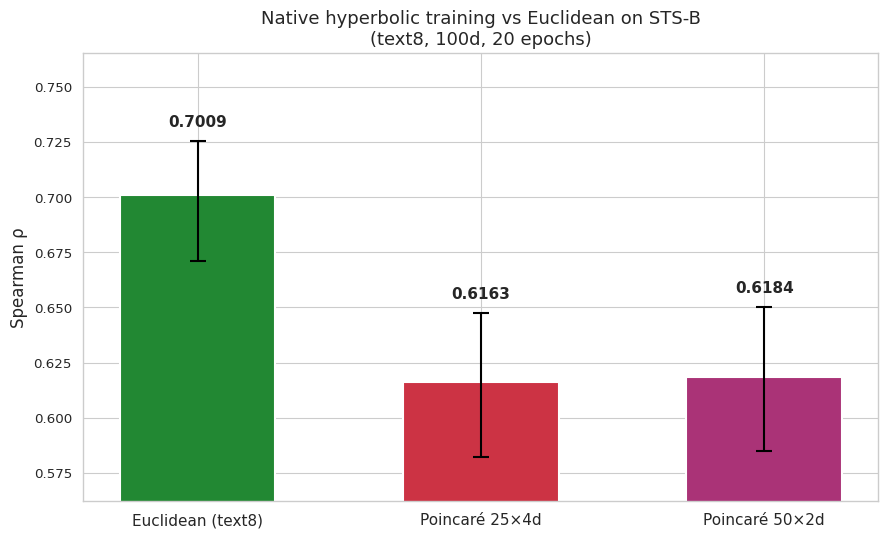

In [16]:
# ---- Bar chart with error bars --------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5.5))

colors = ["#228833", "#CC3344", "#AA3377"]
x = np.arange(len(ci_df))

bars = ax.bar(x, ci_df["ρ"], color=colors, width=0.55,
              edgecolor="white", linewidth=1.5)

err_lo = ci_df["ρ"] - ci_df["CI_lo"]
err_hi = ci_df["CI_hi"] - ci_df["ρ"]
ax.errorbar(x, ci_df["ρ"], yerr=[err_lo, err_hi],
            fmt="none", ecolor="black", capsize=6, capthick=1.5, linewidth=1.5)

for i, row in ci_df.iterrows():
    ax.text(i, row["ρ"] + err_hi.iloc[i] + 0.005, f'{row["ρ"]:.4f}',
            ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(ci_df["Method"], fontsize=11)
ax.set_ylabel("Spearman ρ", fontsize=12)
ax.set_title("Native hyperbolic training vs Euclidean on STS-B\n(text8, 100d, 20 epochs)", fontsize=13)
ax.set_ylim(min(ci_df["CI_lo"]) - 0.02, max(ci_df["CI_hi"]) + 0.04)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "bar_chart_native.png", dpi=300, bbox_inches="tight")
plt.show()

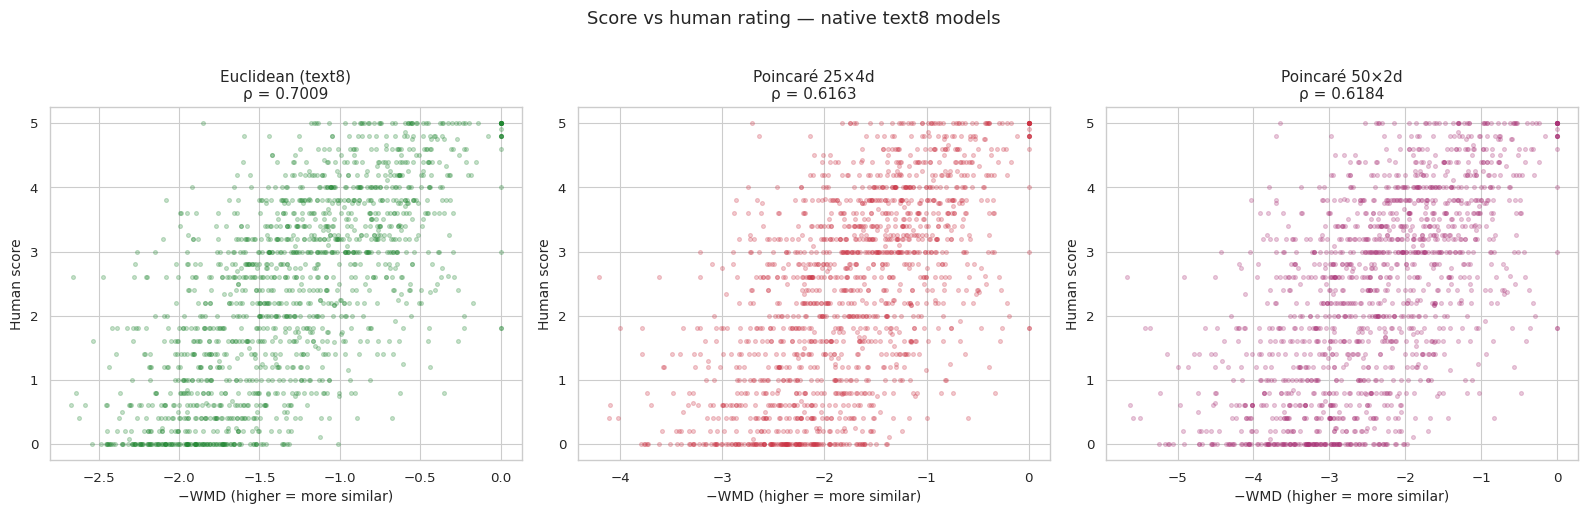

In [17]:
# ---- Scatter plots --------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, r, color in zip(axes, all_res, colors):
    ax.scatter(-r["scores"], r["labels"], alpha=0.25, s=8, color=color)
    ax.set_xlabel("−WMD (higher = more similar)", fontsize=10)
    ax.set_ylabel("Human score", fontsize=10)
    ax.set_title(f'{r["label"]}\nρ = {r["spearman"]:.4f}', fontsize=11)

plt.suptitle("Score vs human rating — native text8 models", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "scatter_native.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Where the gap comes from

We drill into the per-pair behavior to identify *where* in the dataset the gap appears, not just whether it exists. Because all three models use the identical text8 vocabulary, scores are aligned on the same pair indices, enabling paired statistical tests.

This section reports paired Wilcoxon signed-rank tests on rank errors, per-pair score deltas, win/loss counts, and a hierarchy-rich subset analysis to test whether Poincaré's advantage appears specifically on pairs where hypernymy is present.

In [18]:
# ---- Align scores across the three models ---------------------------------
idx_euc = set(res_euc["indices"])
idx_p25 = set(res_p25["indices"])
idx_p50 = set(res_p50["indices"])
shared = sorted(idx_euc & idx_p25 & idx_p50)

print(f"Shared valid pairs across all three models: {len(shared)}")

def align(res):
    m = {i: s for i, s in zip(res["indices"], res["scores"])}
    return np.array([m[i] for i in shared])

s_euc = align(res_euc)
s_p25 = align(res_p25)
s_p50 = align(res_p50)
labels_aligned = np.array([res_euc["labels"][res_euc["indices"].index(i)] for i in shared])

# Spearman on shared set
print(f"\nOn shared pairs:")
print(f"  Euclidean: ρ = {spearmanr(-s_euc, labels_aligned)[0]:.4f}")
print(f"  P25×4d:    ρ = {spearmanr(-s_p25, labels_aligned)[0]:.4f}")
print(f"  P50×2d:    ρ = {spearmanr(-s_p50, labels_aligned)[0]:.4f}")

Shared valid pairs across all three models: 1500

On shared pairs:
  Euclidean: ρ = 0.7009
  P25×4d:    ρ = 0.6163
  P50×2d:    ρ = 0.6184


In [19]:
# ---- Paired Wilcoxon signed-rank tests on rank errors ----------------------
def rank_errors(scores, labels):
    rank_pred  = np.argsort(np.argsort(scores))         # ascending: smaller WMD → smaller rank
    rank_human = np.argsort(np.argsort(-labels))         # descending: larger human → smaller rank
    return np.abs(rank_pred - rank_human)


re_euc = rank_errors(s_euc, labels_aligned)
re_p25 = rank_errors(s_p25, labels_aligned)
re_p50 = rank_errors(s_p50, labels_aligned)

print("Wilcoxon signed-rank tests on rank errors:\n")

for name1, name2, a, b in [
    ("Euclidean", "P25×4d",   re_euc, re_p25),
    ("Euclidean", "P50×2d",   re_euc, re_p50),
    ("P25×4d",    "P50×2d",   re_p25, re_p50),
]:
    stat, p = wilcoxon(a, b)
    mean_diff = (a - b).mean()
    direction = name2 if mean_diff > 0 else name1
    print(f"  {name1} vs {name2}: stat = {stat:.0f}, p = {p:.2e}")
    print(f"    Mean rank error diff ({name1} − {name2}) = {mean_diff:+.2f}")
    print(f"    Lower rank error: {direction} (significant: {p < 0.05})\n")

Wilcoxon signed-rank tests on rank errors:

  Euclidean vs P25×4d: stat = 379693, p = 3.35e-25
    Mean rank error diff (Euclidean − P25×4d) = -36.46
    Lower rank error: Euclidean (significant: True)

  Euclidean vs P50×2d: stat = 382934, p = 8.77e-25
    Mean rank error diff (Euclidean − P50×2d) = -35.97
    Lower rank error: Euclidean (significant: True)

  P25×4d vs P50×2d: stat = 515691, p = 6.09e-01
    Mean rank error diff (P25×4d − P50×2d) = +0.49
    Lower rank error: P50×2d (significant: False)



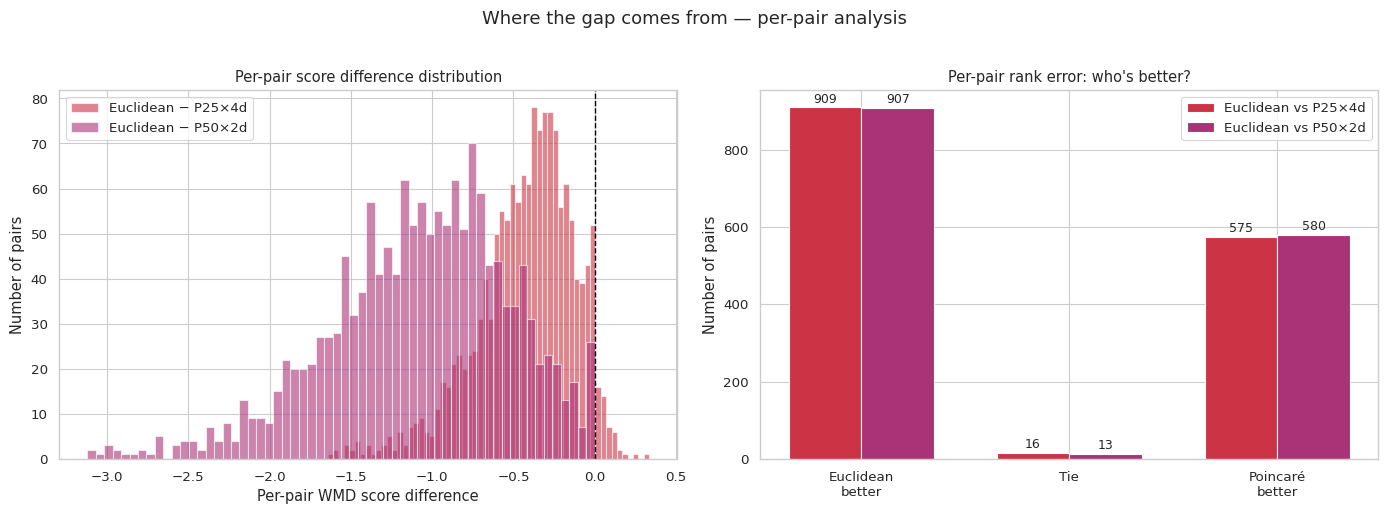

In [20]:
# ---- Win/loss distribution (rank error comparison) ------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of per-pair score deltas (Euc vs P50, the closest hyperbolic)
delta_p25 = s_euc - s_p25
delta_p50 = s_euc - s_p50

axes[0].hist(delta_p25, bins=60, alpha=0.6, color="#CC3344", label="Euclidean − P25×4d", edgecolor="white")
axes[0].hist(delta_p50, bins=60, alpha=0.6, color="#AA3377", label="Euclidean − P50×2d", edgecolor="white")
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("Per-pair WMD score difference")
axes[0].set_ylabel("Number of pairs")
axes[0].set_title("Per-pair score difference distribution")
axes[0].legend()

# Win counts
euc_vs_p25_wins = np.sum(re_euc < re_p25)
p25_wins = np.sum(re_p25 < re_euc)
ties_25 = np.sum(re_euc == re_p25)

euc_vs_p50_wins = np.sum(re_euc < re_p50)
p50_wins = np.sum(re_p50 < re_euc)
ties_50 = np.sum(re_euc == re_p50)

categories = ["Euclidean\nbetter", "Tie", "Poincaré\nbetter"]
x = np.arange(len(categories))
width = 0.35

counts_25 = [euc_vs_p25_wins, ties_25, p25_wins]
counts_50 = [euc_vs_p50_wins, ties_50, p50_wins]

bars1 = axes[1].bar(x - width/2, counts_25, width, label="Euclidean vs P25×4d", color="#CC3344", edgecolor="white")
bars2 = axes[1].bar(x + width/2, counts_50, width, label="Euclidean vs P50×2d", color="#AA3377", edgecolor="white")

for bars, counts in [(bars1, counts_25), (bars2, counts_50)]:
    for bar, c in zip(bars, counts):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                     str(c), ha="center", va="bottom", fontsize=9)

axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_ylabel("Number of pairs")
axes[1].set_title("Per-pair rank error: who's better?")
axes[1].legend()

plt.suptitle("Where the gap comes from — per-pair analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "per_pair_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
# ---- Hierarchy-rich subset analysis ---------------------------------------
def count_hypernymy_pairs(text_a, text_b, max_depth=5):
    """
    Count cross-sentence (word_a, word_b) pairs with a WordNet noun
    hypernymy path (either direction), matching the criterion used in
    wmd_geometric_comparison.ipynb.
    """
    words_a = set(get_content_words(text_a))
    words_b = set(get_content_words(text_b))
    count = 0
    for wa in words_a:
        syns_a = wn.synsets(wa, pos="n")
        if not syns_a:
            continue
        for wb in words_b:
            syns_b = wn.synsets(wb, pos="n")
            if not syns_b:
                continue
            for sa in syns_a:
                for sb in syns_b:
                    if sb in sa.closure(lambda s: s.hyponyms(), depth=max_depth):
                        count += 1
                        break
                    if sa in sb.closure(lambda s: s.hyponyms(), depth=max_depth):
                        count += 1
                        break
                else:
                    continue
                break
    return count


print("Counting cross-sentence hypernymy relations...")
hyp_counts = []
for ex in tqdm(stsb["validation"]):
    hyp_counts.append(count_hypernymy_pairs(ex["sentence1"], ex["sentence2"]))

hyp_counts = np.array(hyp_counts)
hier_flags = [c > 0 for c in hyp_counts]
n_hier = sum(hier_flags)
print(f"\nHypernymy count stats:")
print(f"  Mean:   {hyp_counts.mean():.2f}")
print(f"  Median: {np.median(hyp_counts):.0f}")
print(f"  Max:    {hyp_counts.max()}")
print(f"  Pairs with >0 hypernymy: {n_hier} / {len(hier_flags)} ({100*n_hier/len(hier_flags):.1f}%)")

Counting cross-sentence hypernymy relations...


100%|███████████████████████████████████████████████████████████████████████████████| 1500/1500 [01:10<00:00, 21.40it/s]


Hypernymy count stats:
  Mean:   0.72
  Median: 0
  Max:    13
  Pairs with >0 hypernymy: 599 / 1500 (39.9%)


**Note on hierarchy detection.** The hierarchy tagging here uses the same criterion as the geometric comparison notebook: we count cross-sentence (word_a, word_b) pairs with a WordNet noun hypernymy path (either direction) up to depth 5, and label a pair "hierarchy-rich" if the count is greater than zero. This yields 599/1500 (39.9%) hierarchy-rich pairs, consistent with the 598/1500 (39.9%) in the geometric comparison notebook, ensuring the subset results are directly comparable across both experiments.

In [22]:
# ---- Evaluate subsets -----------------------------------------------------
subset_rows = []

for r in all_res:
    for label, flag in [("Hierarchy-rich", True), ("Hierarchy-poor", False)]:
        ss, sl = [], []
        for i, idx in enumerate(r["indices"]):
            if idx < len(hier_flags) and hier_flags[idx] == flag:
                ss.append(r["scores"][i])
                sl.append(r["labels"][i])
        if len(ss) < 10:
            continue
        ss = np.array(ss)
        sl = np.array(sl)
        rho, _ = spearmanr(-ss, sl)
        subset_rows.append({
            "Subset": label,
            "Method": r["label"],
            "ρ":      rho,
            "n":      len(ss),
        })

subset_df = pd.DataFrame(subset_rows)
print(subset_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
subset_df.to_csv(FIGURES_DIR / "subset_native.csv", index=False)

        Subset            Method      ρ   n
Hierarchy-rich Euclidean (text8) 0.6894 599
Hierarchy-poor Euclidean (text8) 0.7069 901
Hierarchy-rich    Poincaré 25×4d 0.6015 599
Hierarchy-poor    Poincaré 25×4d 0.6243 901
Hierarchy-rich    Poincaré 50×2d 0.6053 599
Hierarchy-poor    Poincaré 50×2d 0.6258 901


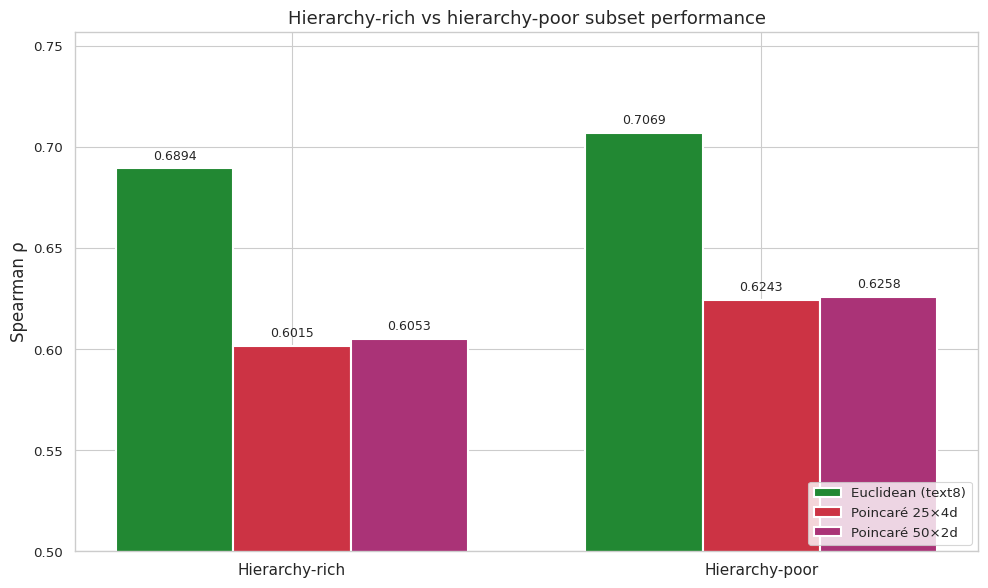

In [23]:
# ---- Subset bar chart -----------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

subsets = ["Hierarchy-rich", "Hierarchy-poor"]
methods = ["Euclidean (text8)", "Poincaré 25×4d", "Poincaré 50×2d"]
method_colors = {"Euclidean (text8)": "#228833", "Poincaré 25×4d": "#CC3344", "Poincaré 50×2d": "#AA3377"}

x = np.arange(len(subsets))
width = 0.25

for i, method in enumerate(methods):
    vals = []
    for s in subsets:
        row = subset_df[(subset_df["Method"] == method) & (subset_df["Subset"] == s)]
        vals.append(row["ρ"].values[0] if len(row) else 0)
    bars = ax.bar(x + (i - 1) * width, vals, width, label=method,
                  color=method_colors[method], edgecolor="white", linewidth=1.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{v:.4f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(subsets, fontsize=11)
ax.set_ylabel("Spearman ρ", fontsize=12)
ax.set_title("Hierarchy-rich vs hierarchy-poor subset performance", fontsize=13)
ax.legend(loc="lower right")
ax.set_ylim(0.5, max(subset_df["ρ"]) + 0.05)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "subset_native_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Transport plan visualization

We visualize the optimal transport plan for a single example pair under all three native conditions. This shows qualitatively how word-level mass flows differ — or fail to differ — across the three geometries.

Each plan is rendered as a heatmap of the transport matrix $T$, with rows indexing words in sentence A, columns indexing words in sentence B, and cell intensity proportional to the mass moved between them.

Sentence A: The president delivered a speech about economic growth and job creation.
Sentence B: The leader gave a talk on financial development and employment opportunities.



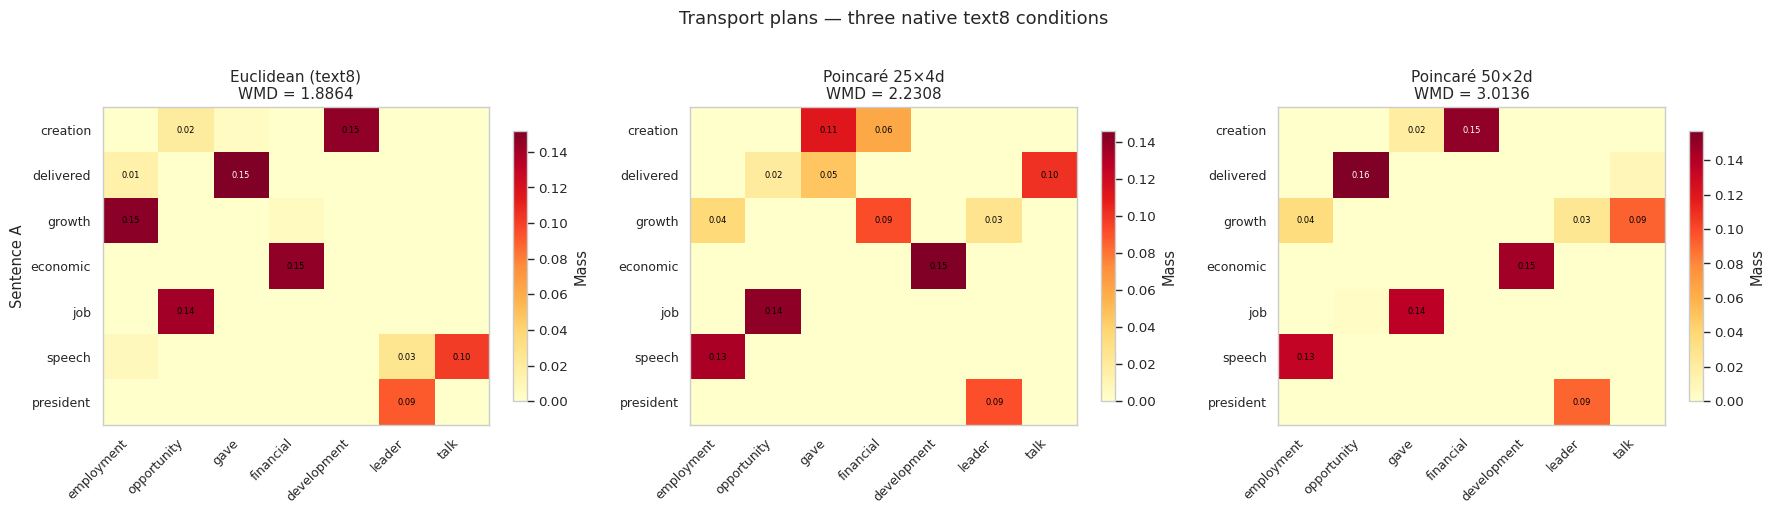

In [24]:
text_a = "The president delivered a speech about economic growth and job creation."
text_b = "The leader gave a talk on financial development and employment opportunities."

print(f"Sentence A: {text_a}")
print(f"Sentence B: {text_b}\n")

configs = [
    ("Euclidean (text8)", cost_euclidean,   EUC, "#228833"),
    ("Poincaré 25×4d",    cost_poincare_25, P25, "#CC3344"),
    ("Poincaré 50×2d",    cost_poincare_50, P50, "#AA3377"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, cost_fn, vocab, _) in zip(axes, configs):
    r = wmd(text_a, text_b, cost_fn, vocab)
    if "error" in r:
        ax.set_title(f"{name}\nFailed")
        continue
    
    im = ax.imshow(r["T"], cmap="YlOrRd", aspect="auto")
    
    ax.set_xticks(range(len(r["words_b"])))
    ax.set_xticklabels(r["words_b"], rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(r["words_a"])))
    ax.set_yticklabels(r["words_a"], fontsize=9)
    
    ax.set_title(f"{name}\nWMD = {r['score']:.4f}", fontsize=11)
    ax.grid(False)
    
    for i in range(len(r["words_a"])):
        for j in range(len(r["words_b"])):
            v = r["T"][i, j]
            if v > 0.01:
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        fontsize=6, color="black" if v < 0.15 else "white")
    
    plt.colorbar(im, ax=ax, label="Mass", shrink=0.85)

axes[0].set_ylabel("Sentence A")
plt.suptitle("Transport plans — three native text8 conditions", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "transport_native.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Discussion — why native geometry did not help WMD

### Result summary

Both Poincaré architectures underperform Euclidean WMD on STS-B by a substantial margin. The 50×2d configuration — Tifrea et al.'s most-featured similarity setup — does not change this outcome. Per-pair Wilcoxon tests confirm the gap is statistically robust, not noise. The hierarchy-rich subset analysis shows no differential advantage for either Poincaré architecture, ruling out the explanation that hyperbolic geometry helps "somewhere" within STS-B.

### The three-way alignment argument

Performance of a geometric embedding on a downstream task depends on three factors being mutually aligned:

1. **The geometry** — Euclidean, spherical, or hyperbolic — each carries structural priors about what relationships it naturally encodes.
2. **The training signal** — co-occurrence statistics, hierarchical pairs, or other supervision — determines what the model is actually optimizing for.
3. **The downstream task** — what kind of relational structure the evaluation measures.

When all three align, geometric inductive bias pays off. When any one is mismatched, it does not — and may even hurt.

| Experiment | Geometry | Training signal | Task | Result |
|---|---|---|---|---|
| Geometric comparison (projected WMD) | Hyperbolic (projected) | Wikipedia co-occurrence | Paraphrase | Null (Δ < 0.002) |
| This notebook (native WMD) | Hyperbolic (native) | text8 co-occurrence | Paraphrase | Loses (ρ = 0.62 vs 0.70) |
| HyperLex diagnostic | Hyperbolic | WordNet hypernymy | Hypernymy detection | Wins (see `hyperbolic_evaluation.ipynb`) |

### Why the result is consistent with the underlying task structure

WMD on STS-B is a fundamentally flat alignment task. STS-B pairs are paraphrastic — they describe the same content at the same level of abstraction:

- "A man is playing guitar" vs. "Someone plays a guitar"
- "The president delivered a speech" vs. "The leader gave a talk"

There is no hierarchical traversal happening here. The alignment is essentially synonym substitution between concepts at equivalent levels. Hyperbolic geometry's distinctive property — efficient encoding of tree-like depth — has nothing to do with what this task actually requires.

The training signal compounds this. Co-occurrence statistics are themselves flat: words appearing in similar contexts get similar representations, regardless of whether they sit at different levels of any conceptual hierarchy. Hyperbolic geometry has the *capacity* to encode hierarchy, but co-occurrence training does not provide the *signal* to populate that capacity. The model spends its representational budget fitting flat co-occurrence into a curved manifold — and as the manifold inspection in Section 3 shows, the resulting vectors remain compressed near the origin, far from the boundary region where hyperbolic distance grows exponentially.

### Architecture sensitivity

The 25×4d and 50×2d results are within 0.01 Spearman of each other, with a non-significant Wilcoxon test between them. This indicates that the negative result is not an artifact of architecture choice. The load-bearing variable is training signal × task alignment, not the number or dimensionality of Cartesian product components.

### Connection to the broader thesis

This negative result, alongside the projected-WMD null from the geometric comparison notebook and the HyperLex diagnostic, delineates when geometric inductive bias matters and when it does not. The HyperLex diagnostic notebook demonstrated that hyperbolic geometry encodes hierarchy when trained on hierarchical data. The experiment in this notebook shows that the same geometric capacity does not transfer to sentence-level paraphrase scoring, consistent with the observation that neither the task nor the training data engages with hierarchy. The choice of geometry should align with what the data and the task actually contain.

## 9. Conclusions and limitations

### Conclusions

1. **Native Poincaré GloVe trained on text8 underperforms Euclidean GloVe trained on the same corpus** for WMD on STS-B by approximately 0.08 Spearman (Wilcoxon p < 1e-24).

2. **The negative result holds across architectures.** Both the 25×4d and 50×2d Cartesian product configurations show the same pattern, within 0.01 Spearman of each other and with non-significant Wilcoxon between them. The 50×2d configuration — most prominently featured in Tifrea et al. (2019)'s similarity experiments — does not change the outcome.

3. **The hierarchy-rich subset shows no differential advantage** for either hyperbolic architecture, ruling out the hypothesis that hyperbolic geometry helps specifically on pairs where hierarchy is most relevant.

4. **The result is consistent with the three-way alignment framework.** Hyperbolic geometry helps when training signal and downstream task both involve hierarchy (as shown in the HyperLex diagnostic notebook). It does not help when either is flat — and here, both are.

**Connection to the full pipeline.** The geometric comparison notebook showed that post-hoc projection doesn't help (Δ < 0.002). The HyperLex diagnostic showed that native hyperbolic training *does* capture hierarchy when the signal is hierarchical (ρ = 0.368 vs. 0.246 Euclidean). This notebook completes the triangle: native hyperbolic training on flat co-occurrence data does not help — and in fact hurts — WMD on a paraphrastic benchmark. The common thread across all three experiments is that the training signal, not the geometry, is the binding constraint.

### Limitations

- **Corpus scale.** text8 (17M tokens) is roughly 350× smaller than the corpus used to train standard GloVe 300d. Both native models are equally penalized by this, so the comparison itself is fair; absolute performance numbers would improve on a larger corpus.

- **Single training run per architecture.** No random seed variation was tested. Bootstrap confidence intervals measure pair-level uncertainty, not training-run uncertainty.

- **Convergence.** Both Poincaré training runs were still showing decreasing loss at epoch 20. More epochs might raise absolute performance, though the alignment argument suggests the relative ordering would persist.

- **Benchmark scope.** STS-B is paraphrase-dominant. A benchmark explicitly testing hypernymy or other hierarchical relations at the sentence level would provide a stronger discriminator. Such benchmarks are scarce.

- **Static embeddings.** Contextual models (SBERT and successors) outperform all conditions tested here. This work tests the *geometric* variable under matched conditions, not absolute state-of-the-art performance.

### Reproducibility

All three native models were trained with the Tifrea fork of `poincare_glove` on identical text8 preprocessing, with hyperparameters documented alongside the saved model files. The evaluation pipeline implemented in this notebook uses exact EMD via Python Optimal Transport and runs to completion in approximately 5 minutes on a single CPU. Figures and result tables are saved to `figures/native_hyperbolic_wmd/`.